### Imports

In [235]:
import os
import pandas as pd
import numpy as np
import healpy as hp
import matplotlib.pyplot as plt
import seaborn as sns
# sns.set_style("darkgrid")
# sns.set(rc={"xtick.bottom": True, "ytick.left": True})
from astropy.constants import c, k_B, R_earth
import src.read_database as read_database
import src.map_properties as map_properties
import src.satellite_properties as satellite_properties
import src.store_FOV_indices as store_FOV_indices
import src.Friis as Friis
import src.power_3D_cube as power_3D_cube
import time
%matplotlib inline   

In [2]:
start_time=time.time()

#### Schematic representation of the architecture

![image](./rfi_framework.png)

### Read FM Transmitter Database 

In [3]:
n = str(input("Enter the number of countries to include"))

Enter the number of countries to includeAll


In [4]:
df = read_database.read_FM_database(countries=read_database.get_countries(n))

/home/saurabhs/Documents/Yogen_starfire/STARFIRE_2_backup/Project/src/read_database.py:76: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, read_csv(f"./database/{countries[i+1]}")], ignore_index=True)
/home/saurabhs/Documents/Yogen_starfire/STARFIRE_2_backup/Project/src/read_database.py:76: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, read_csv(f"./database/{countries[i+1]}")], ignore_index=True)


### Define frequency range  

In [5]:
freq_range = read_database.get_freq_range()

Please enter the minimum value of the frequency range (in MHz): 55
Please enter the maximum value of the frequency range (in MHz): 110
Please enter the resolution of the frequency (in MHz): 0.244


In [6]:
df = read_database.extract_common_freq(df, freq_range)


### Define resolution of the Healpy map

In [7]:
print('----------- Resolution of the map -----------')

# The default value of nside is 16
nside = int(input("Enter the NSIDE of the healpy map"))
npix, pix_array, phi, theta = map_properties.get_map(nside)

print(f"The number of pixels for the given NSIDE: {(hp.nside2npix(nside))}")
print(f"Approximate resolution in degrees for given nside {np.degrees(hp.nside2resol(nside)):.2f}")
print(f"Pixel area: {hp.nside2pixarea(nside, degrees=True):.2f} square degrees")

----------- Resolution of the map -----------
Enter the NSIDE of the healpy map32
The number of pixels for the given NSIDE: 12288
Approximate resolution in degrees for given nside 1.83
Pixel area: 3.36 square degrees


In [8]:
beam_pattern=str(input('Enter desired beam pattern:'))

Enter desired beam pattern:cos square


### Allocate pixel number to the Latitude and Longitude of each FM transmitter in the database

In [9]:
df, pixel_indices = read_database.allocate_pixel_num(nside, df)


### Define altitude of the satellite orbit 

In [10]:
altitudes = satellite_properties.get_altitudes()

Enter desired altitudes:410 650 705


### Calculation of Elevation angle

In [11]:
elev_angle = satellite_properties.calc_elev_angle(npix, phi, theta, altitudes)

/home/saurabhs/Documents/Yogen_starfire/STARFIRE_2_backup/Project/src/satellite_properties.py:46: RuntimeWarning: divide by zero encountered in scalar divide
  elev_ang[k, i, j] = -(np.degrees(np.arctan((B - cos_theta_j) / sin_y_ang)))
/home/saurabhs/Documents/Yogen_starfire/STARFIRE_2_backup/Project/src/satellite_properties.py:41: RuntimeWarning: invalid value encountered in arccos
  y_ang = np.arccos(x_ang)


### Define radiation pattern of the satellite antenna beam [optional]

In [12]:
np.shape(elev_angle)

(3, 12288, 12288)

In [13]:
beam = satellite_properties.get_beam_pattern("sin square", theta)
az = 0 # Assuming the satellite antenna beam to be symmetric across azimuth

###  Calculation of Field of view (FOV) and Radius of the FOV of the satellite

In [14]:
FOV = satellite_properties.calc_field_of_view(altitudes)

The Field of view of the satellite at a height of 410.00 km is 2.44 radians
The Field of view of the satellite at a height of 650.00 km is 2.27 radians
The Field of view of the satellite at a height of 705.00 km is 2.24 radians


In [15]:
Central_angle, Rad_of_FOV = satellite_properties.calc_central_angle(altitudes)

The Radius of the Field of View for a height of 410.00 km in radians is 0.35
The Radius of the Field of View for a height of 650.00 km in radians is 0.43
The Radius of the Field of View for a height of 705.00 km in radians is 0.45


# Create power cube 

In [16]:
disc = store_FOV_indices.get_disc(nside, phi, theta, Rad_of_FOV, pix_array)

In [17]:
pix_common = store_FOV_indices.get_common_pix(pix_array, Rad_of_FOV, disc, df)

In [18]:
found_common = store_FOV_indices.get_common_Tx(pixel_indices, pix_common, Rad_of_FOV)

## Plot Healpy map of beam-weighted FOV of a satellite overhead a particular location

<b> Transmitter locations from the FM Transmitter database and the received power at different altitudes has not been taken into account for these plots <b>

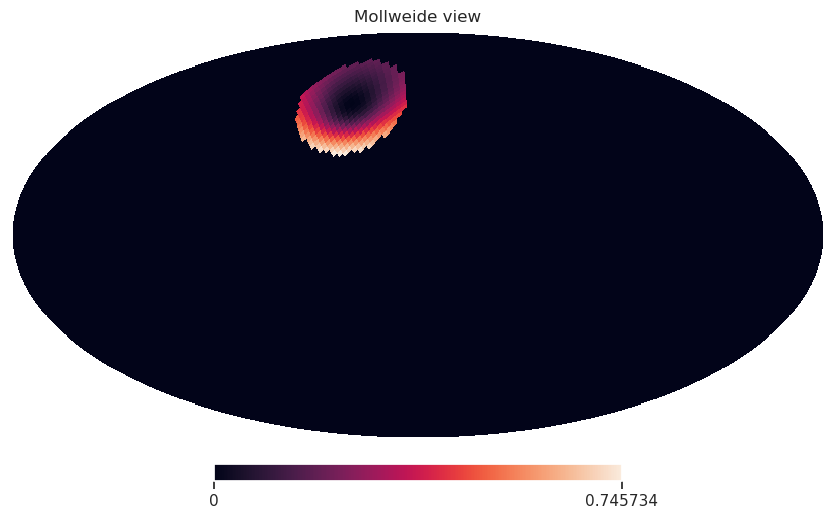

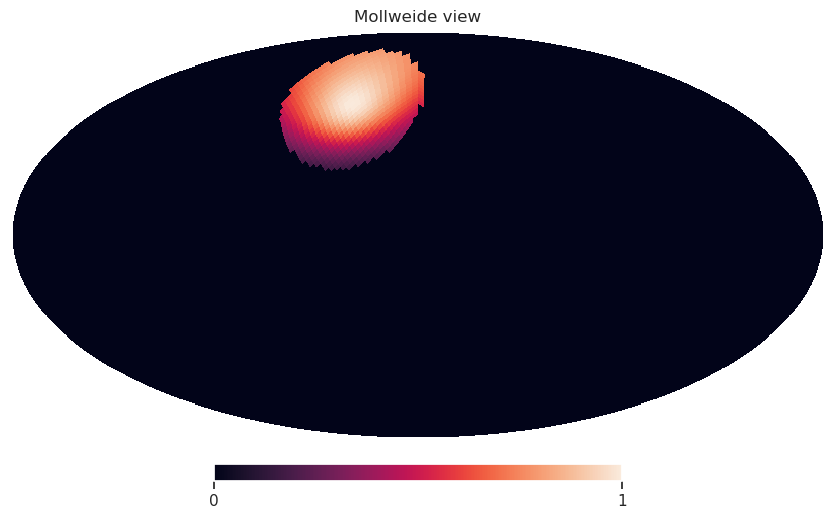

In [19]:
i=1500
xx4=disc[i][0]  # For Hanle at an altitude of 400 km
xx5=disc[686][1]
xx6=disc[i][2]

y4=satellite_properties.get_beam_pattern("cos square", elev_angle[0,i,xx4])
y5=satellite_properties.get_beam_pattern("cos square", elev_angle[1,686,xx5])
y6=satellite_properties.get_beam_pattern("sin square", elev_angle[2,i,xx6])

data4= np.zeros(hp.nside2npix(nside))
data5= np.zeros(hp.nside2npix(nside))
data6= np.zeros(hp.nside2npix(nside))

data4[xx4]=y4
data5[xx5]=y5

data6[xx6]=y6

hp.mollview(data4,flip='geo')
# hp.mollview(data5,flip='geo')
hp.mollview(data6,flip='geo')

In [20]:
Rx_Power_in_Kelvin = Friis.calc_Friis(df, altitudes)[2]
# print(df)

/home/saurabhs/Documents/Yogen_starfire/STARFIRE_2_backup/Project/src/Friis.py:30: RuntimeWarning: divide by zero encountered in log10
  Rx_Power_in_dBm[j][i]= 10.*np.log10( Rx_Power[j][i])+30
/home/saurabhs/Documents/Yogen_starfire/STARFIRE_2_backup/Project/src/Friis.py:32: RuntimeWarning: divide by zero encountered in log10
  Rx_Power_in_dBW[j][i]= 10.*np.log10( Rx_Power[j][i])


In [21]:
df_fov = power_3D_cube.get_dataframe_fov(Rx_Power_in_Kelvin, df, found_common, Rad_of_FOV, elev_angle,beam_pattern)

In [22]:
power_output = power_3D_cube.get_power_output(npix, Rad_of_FOV, freq_range, df_fov)

In [23]:
end_time=time.time()

In [24]:
execution_time = end_time - start_time

print(f"Execution time: {execution_time/60} minutes")

Execution time: 111.50973609288533 minutes


## Plot  Spectrum 

<b> The first index represents altitude of the satellite <b>\
<b> The second index represents location of the satellite(pixel number) <b>\
<b> The third index represents range of frequencies <b>

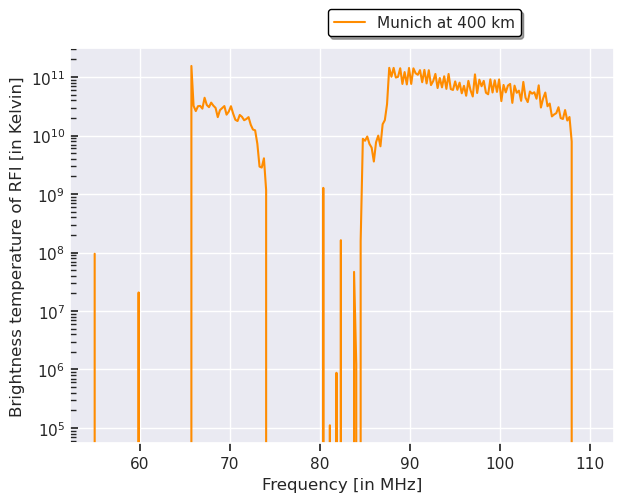

In [25]:
sns.set_style("darkgrid")
sns.set(rc={"xtick.bottom": True, "ytick.left": True,
            "xtick.direction": "out", "ytick.direction": "in"}) #, "axes.edgecolor": "black"})
munpix=hp.ang2pix(nside, 11.580224258292716,48.13469781361046,lonlat=True)
plt.plot(freq_range,power_output[0,munpix,:], label='Munich at 400 km', color='darkorange') 
plt.xlabel('Frequency [in MHz]')
plt.ylabel('Brightness temperature of RFI [in Kelvin]')
plt.yscale('log')
plt.tight_layout()
plt.legend(facecolor="white", edgecolor="black", bbox_to_anchor=(0.46, 1.01),fancybox=True, shadow=True)
# plt.savefig("/home/sonia/Documents/RFI_PAPER/Munich_36000_new.pdf")

In [1110]:
altitudes[0]

410.0

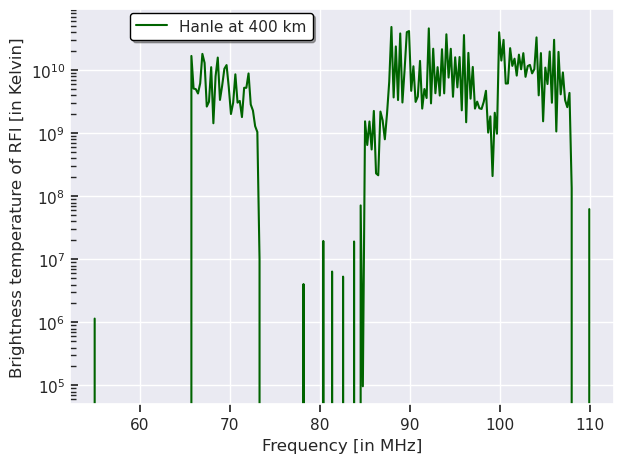

In [1111]:
sns.set_style("darkgrid")
sns.set(rc={"xtick.bottom": True, "ytick.left": True,
            "xtick.direction": "out", "ytick.direction": "in"}) #, "axes.edgecolor": "black"})
hanlepix=hp.ang2pix(nside, 79.00064650939689,32.79063979504319,lonlat=True)
plt.plot(freq_range,power_output[0,hanlepix,:], label='Hanle at 400 km', color='darkgreen') 
plt.xlabel('Frequency [in MHz]')
plt.ylabel('Brightness temperature of RFI [in Kelvin]')
plt.yscale('log')
plt.tight_layout()
plt.legend(facecolor="white", edgecolor="black", bbox_to_anchor=(0.46, 1.01),fancybox=True, shadow=True)
# plt.savefig('/home/saurabhs/Documents/Yogen_starfire/SF_images/India_spec.pdf')

In [27]:
num_of_rfi_chan=len(freq_range[power_output[0,13,:]!=0])
num_of_rfi_chan


#NUM_OF_RFI_CHANNEL=96 (Arctic Ocean at 36000 km (Tokyo, USA, Germany,\n Canada, Australia and South Africa)
#NUM_OF_RFI_CHANNEL=84 (Arctic Ocean at 3795 km (Tokyo, USA, Germany,\n Canada, Australia and South Africa)
#NUM_OF_RFI_CHANNEL=0 (Arctic Ocean at 400 km (Tokyo, USA, Germany,\n Canada, Australia and South Africa)



#NUM_OF_RFI_CHANNEL=83 (Pacific Ocean at 36000 km (Tokyo, USA, Germany,\n Canada, Australia and South Africa)
#NUM_OF_RFI_CHANNEL=3 (Pacific Ocean at 3795 km (Tokyo, USA, Germany,\n Canada, Australia and South Africa)
#NUM_OF_RFI_CHANNEL=0 (Pacic Ocean at 400 km (Tokyo, USA, Germany,\n Canada, Australia and South Africa)




#NUM_OF_RFI_CHANNEL=96 (Arctic Ocean at 36000 km (Tokyo, USA, Germany,\n Canada, Australia)
#NUM_OF_RFI_CHANNEL=84 (Arctic Ocean at 3795 km (Tokyo, USA, Germany,\n Canada, Australia)
#NUM_OF_RFI_CHANNEL=0 (Arctic Ocean at 400 km (Tokyo, USA, Germany,\n Canada, Australia)

#NUM_OF_RFI_CHANNEL=83 (Pacific Ocean at 36000 km (Tokyo, USA, Germany,\n Canada, Australia)
#NUM_OF_RFI_CHANNEL=3 (Paciic Ocean at 3795 km (Tokyo, USA, Germany,\n Canada, Australia)
#NUM_OF_RFI_CHANNEL=0 (Pacitic Ocean at 400 km (Tokyo, USA, Germany,\n Canada, Australia)





#NUM_OF_RFI_CHANNEL=96 (Arctic Ocean at 36000 km (Tokyo, USA, Germany,\n Canada)
#NUM_OF_RFI_CHANNEL=84 (Arctic Ocean at 3795 km (Tokyo, USA, Germany,\n Canada)
#NUM_OF_RFI_CHANNEL=0 (Arctic Ocean at 400 km (Tokyo, USA, Germany,\n Canada,)

#NUM_OF_RFI_CHANNEL=83 (Pacific Ocean at 36000 km (Tokyo, USA, Germany,\n Canada,)
#NUM_OF_RFI_CHANNEL=3 (Paciic Ocean at 3795 km (Tokyo, USA, Germany,\n Canada,)
#NUM_OF_RFI_CHANNEL=0 (Pacitic Ocean at 400 km (Tokyo, USA, Germany,\n Canada)







#NUM_OF_RFI_CHANNEL=96 (Arctic Ocean at 36000 km (Tokyo, USA, Germany)
#NUM_OF_RFI_CHANNEL=84 (Arctic Ocean at 3795 km (Tokyo, USA, Germany)
#NUM_OF_RFI_CHANNEL=0 (Arctic Ocean at 400 km (Tokyo, USA, Germany)

#NUM_OF_RFI_CHANNEL=13 (Pacific Ocean at 36000 km (Tokyo, USA, Germany)
#NUM_OF_RFI_CHANNEL=3 (Paciic Ocean at 3795 km (Tokyo, USA, Germany)
#NUM_OF_RFI_CHANNEL=0 (Pacitic Ocean at 400 km (Tokyo, USA, Germany)






#NUM_OF_RFI_CHANNEL=32 (Arctic Ocean at 36000 km (Tokyo, USA)
#NUM_OF_RFI_CHANNEL=12 (Arctic Ocean at 3795 km (Tokyo, USA)
#NUM_OF_RFI_CHANNEL=0 (Arctic Ocean at 400 km (Tokyo, USA)

#NUM_OF_RFI_CHANNEL=12 (Pacific Ocean at 36000 km (Tokyo, USA)
#NUM_OF_RFI_CHANNEL=2 (Paciic Ocean at 3795 km (Tokyo, USA)
#NUM_OF_RFI_CHANNEL=0 (Pacitic Ocean at 400 km (Tokyo, USA)




#NUM_OF_RFI_CHANNEL=31 (Arctic Ocean at 36000 km (Tokyo)
#NUM_OF_RFI_CHANNEL=11 (Arctic Ocean at 3795 km (Tokyo)
#NUM_OF_RFI_CHANNEL=0 (Arctic Ocean at 400 km (Tokyo)

#NUM_OF_RFI_CHANNEL=10 (Pacific Ocean at 36000 km (Tokyo)
#NUM_OF_RFI_CHANNEL=0(Paciic Ocean at 3795 km (Tokyo)
#NUM_OF_RFI_CHANNEL=0 (Pacitic Ocean at 400 km (Tokyo)




126

In [28]:
rfi_band=244*num_of_rfi_chan # in kHz
rfi_band_inMHz=rfi_band*1e-3
rfi_band_inMHz

30.744

In [29]:
tot_band=freq_range[-1]-freq_range[0]
usable_band=tot_band-rfi_band_inMHz
usable_band


#USABLE_BW=31.576(Arctic Ocean at 36000 km (Tokyo, USA, Germany,\n Canada, Australia and South Africa)
#USABLE_BW_CHANNEL=34.504000000000005 (Arctic Ocean at 3795 km (Tokyo, USA, Germany,\n Canada, Australia and South Africa)
#USABLE_BW=55 (Arctic Ocean at 400 km (Tokyo, USA, Germany,\n Canada, Australia and South Africa)

#USABLE_BW=34.748000000000005(PACIFIC Ocean at 36000 km (Tokyo, USA, Germany,\n Canada, Australia and South Africa)
#USABLE_BW_CHANNEL=54.268(Pacific Ocean at 3795 km (Tokyo, USA, Germany,\n Canada, Australia and South Africa)
#USABLE_BW=55 (Pacific Ocean at 400 km (Tokyo, USA, Germany,\n Canada, Australia and South Africa)



#USABLE_BW=31.576(Arctic Ocean at 36000 km (Tokyo, USA, Germany,\n Canada, Australia )
#USABLE_BW_CHANNEL=34.504000000000005 (Arctic Ocean at 3795 km (Tokyo, USA, Germany,\n Canada, Australia)
#USABLE_BW=55 (Arctic Ocean at 400 km (Tokyo, USA, Germany,\n Canada, Australia )

#USABLE_BW=34.748000000000005(PACIFIC Ocean at 36000 km (Tokyo, USA, Germany,\n Canada, Australia 
#USABLE_BW_CHANNEL=54.268(Pacific Ocean at 3795 km (Tokyo, USA, Germany,\n Canada, Australia)
#USABLE_BW=55 (Pacific Ocean at 400 km (Tokyo, USA, Germany,\n Canada, Australia)




#USABLE_BW=31.576(Arctic Ocean at 36000 km (Tokyo, USA, Germany,\n Canada)
#USABLE_BW_CHANNEL=34.504000000000005 (Arctic Ocean at 3795 km (Tokyo, USA, Germany,\n Canada)
#USABLE_BW=55 (Arctic Ocean at 400 km (Tokyo, USA, Germany,\n Canada)

#USABLE_BW=34.748000000000005(PACIFIC Ocean at 36000 km (Tokyo, USA, Germany,\n Canada,
#USABLE_BW_CHANNEL=54.268(Pacific Ocean at 3795 km (Tokyo, USA, Germany,\n Canada, 
#USABLE_BW=55 (Pacific Ocean at 400 km (Tokyo, USA, Germany,\n Canada, )






#USABLE_BW=31.576(Arctic Ocean at 36000 km (Tokyo, USA,, Germany)
#USABLE_BW_CHANNEL=34.504000000000005 (Arctic Ocean at 3795 km (Tokyo, USA, Germany)
#USABLE_BW=55 (Arctic Ocean at 400 km (Tokyo, USA, Germany)

#USABLE_BW=51.828(Pacific Ocean at 36000 km (Tokyo, USA, Germany)
#USABLE_BW_CHANNEL=54.268(Pacifc Ocean at 3795 km (Tokyo, USA, Germany)
#USABLE_BW=55 (Pacific Ocean at 400 km (Tokyo, USA, Germany)





#USABLE_BW=47.192(Arctic Ocean at 36000 km (Tokyo, USA)
#USABLE_BW_CHANNEL=52.072 (Arctic Ocean at 3795 km (Tokyo, USA)
#USABLE_BW=55 (Arctic Ocean at 400 km (Tokyo, USA)

#USABLE_BW=52.072(Pacific Ocean at 36000 km (Tokyo, USA)
#USABLE_BW_CHANNEL=54.512(Pacifc Ocean at 3795 km (Tokyo, USA)
#USABLE_BW=55 (Pacific Ocean at 400 km (Tokyo, USA)





#USABLE_BW=47.436(Arctic Ocean at 36000 km (Tokyo)
#USABLE_BW_CHANNEL=52.316 (Arctic Ocean at 3795 km (Tokyo)
#USABLE_BW=55 (Arctic Ocean at 400 km (Tokyo)

#USABLE_BW=52.56(Pacific Ocean at 36000 km (Tokyo)
#USABLE_BW_CHANNEL=55(Pacifc Ocean at 3795 km (Tokyo)
#USABLE_BW=55 (Pacific Ocean at 400 km (Tokyo)



24.15599999999995

In [30]:
time=1
FOM=time*usable_band
FOM

#FOM=31.576(Arctic Ocean at 36000 km (Tokyo, USA, Germany,\n Canada, Australia and South Africa) 31.576
#FOM=34.504000000000005(Arctic Ocean at 3795 km (Tokyo, USA, Germany,\n Canada, Australia and South Africa) 34.504000000000005
#FOM=55(Arctic Ocean at 400 km (Tokyo, USA, Germany,\n Canada, Australia and South Africa) 53.048


#FOM=34.748000000000005(Pacific Ocean at 36000 km (Tokyo, USA, Germany,\n Canada, Australia and South Africa) 34.748000000000005
#FOM=54.268(Paciic Ocean at 3795 km (Tokyo, USA, Germany,\n Canada, Australia and South Africa) 34.748000000000005
#FOM=55(Pacific Ocean at 400 km (Tokyo, USA, Germany,\n Canada, Australia and South Africa) 55.0
#---------------------------------------------------------------------------------------------------------

#FOM=31.576(Arctic Ocean at 36000 km (Tokyo, USA, Germany,\n Canada, Australia ) 31.576
#FOM=34.504000000000005(Arctic Ocean at 3795 km (Tokyo, USA, Germany,\n Canada, Australia )34.504000000000005
#FOM=55(Arctic Ocean at 400 km (Tokyo, USA, Germany,\n Canada, Australia )53.048


#FOM=34.748000000000005(Pacific Ocean at 36000 km (Tokyo, USA, Germany,\n Canada, Australia ) 34.748000000000005
#FOM=54.268(Paciic Ocean at 3795 km (Tokyo, USA, Germany,\n Canada, Australia ) 34.748000000000005
#FOM=55(Pacific Ocean at 400 km (Tokyo, USA, Germany,\n Canada, Australia ) 55

#------------------------------------------------------------------------------------------------------------



#FOM=31.576(Arctic Ocean at 36000 km (Tokyo, USA, Germany,\n Canada) 31.576
#FOM=34.504000000000005(Arctic Ocean at 3795 km (Tokyo, USA, Germany) 34.504000000000005
#FOM=55(Arctic Ocean at 400 km (Tokyo, USA, Germany,\n Canada,) 53.048


#FOM=34.748000000000005(Pacific Ocean at 36000 km (Tokyo, USA, Germany,\n Canada) 34.748000000000005
#FOM=54.268(Paciic Ocean at 3795 km (Tokyo, USA, Germany,\n Canada ) 34.748000000000005
#FOM=55(Pacific Ocean at 400 km (Tokyo, USA, Germany,\n Canada ) 55

#---------------------------------------------------------------------------------------------------------------

#FOM=31.576(Arctic Ocean at 36000 km (Tokyo, USA, Germany,) 31.576
#FOM=34.504000000000005(Arctic Ocean at 3795 km (Tokyo, USA, Germany) 34.50
#FOM=55(Arctic Ocean at 400 km (Tokyo, USA, Germany) 53.048


#FOM=51.828(Pacific Ocean at 36000 km (Tokyo, USA, Germany) 34.748000000000005
#FOM=54.268(Paciic Ocean at 3795 km (Tokyo, USA, Germany ) 34.748000000000005
#FOM=55(Pacific Ocean at 400 km (Tokyo, USA, Germany) 55

#---------------------------------------------------------------------------------------------------------------


#FOM=47.192(Arctic Ocean at 36000 km (Tokyo, USA,) 31.576
#FOM=52.072(Arctic Ocean at 3795 km (Tokyo, USA) 34.992
#FOM=55(Arctic Ocean at 400 km (Tokyo, USA) 53.048


#FOM=52.072(Pacific Ocean at 36000 km (Tokyo, USA) 34.748
#FOM=54.512(Paciic Ocean at 3795 km (Tokyo, USA )34.748
#FOM=55(Pacific Ocean at 400 km (Tokyo, USA) 55

#------------------------------------------------------------------------------------------------------------


#FOM=47.436(Arctic Ocean at 36000 km (Tokyo,) 47.192
#FOM=52.316(Arctic Ocean at 3795 km (Tokyo) 52.316
#FOM=55(Arctic Ocean at 400 km (Tokyo) 55


#FOM=52.56(Pacific Ocean at 36000 km (Tokyo) 52.316
#FOM=55(Paciic Ocean at 3795 km (Tokyo ) 54.756
#FOM=55(Pacific Ocean at 400 km (Tokyo) 55

24.15599999999995

In [797]:
FOM_map=np.zeros(hp.nside2npix(nside))
for i in range(len(FOM_map)):
	num_of_rfi_chan=len(freq_range[power_output[0,i,:]!=0])
	rfi_band=0.244*num_of_rfi_chan 
	usable_band=tot_band-rfi_band
	FOM_map[i]+=usable_band

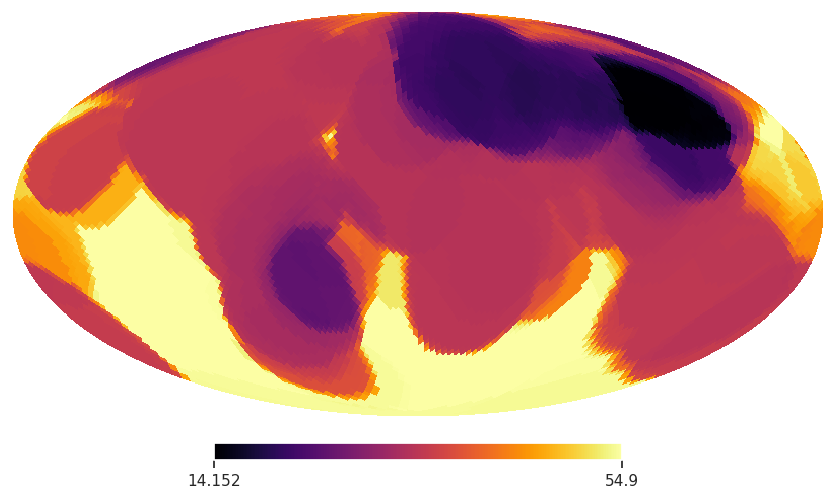

In [798]:
hp.mollview(FOM_map,flip='geo',cmap='inferno',title='')
# plt.savefig('/home/saurabhs/Documents/Yogen_starfire/SF_images/FOM_map.pdf',dpi=600)

In [33]:
np.max(FOM_map)

54.89999999999995

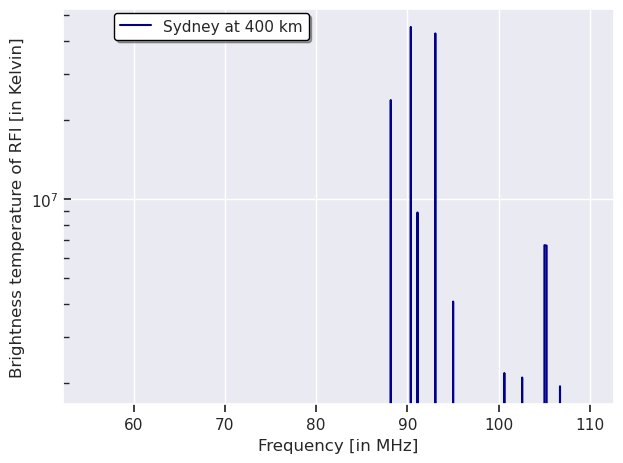

In [34]:
sns.set_style("darkgrid")
sns.set(rc={"xtick.bottom": True, "ytick.left": True,
            "xtick.direction": "out", "ytick.direction": "in"}) #, "axes.edgecolor": "black"})
pix_req=hp.ang2pix(nside,-10,-25,lonlat=True)
plt.plot(freq_range,power_output[0,pix_req,:], label='Sydney at 400 km', color='darkblue') 
plt.xlabel('Frequency [in MHz]')
plt.ylabel('Brightness temperature of RFI [in Kelvin]')
plt.yscale('log')
plt.tight_layout()
plt.legend(facecolor="white", edgecolor="black", bbox_to_anchor=(0.46, 1.01),fancybox=True, shadow=True)

# plt.savefig("/home/sonia/Documents/RFI_PAPER/Sydney_400_new.pdf")

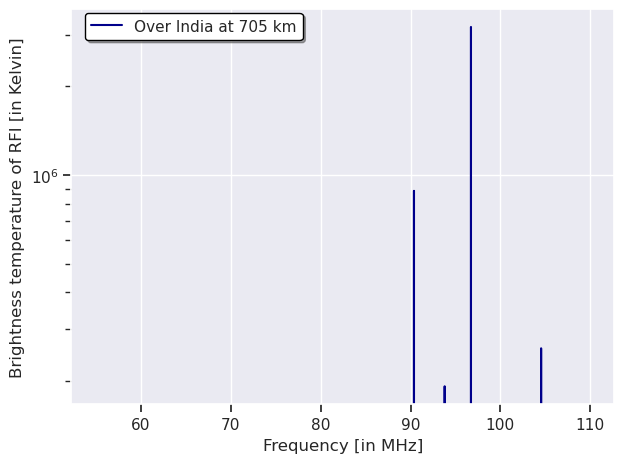

In [764]:
import seaborn as sns
sns.set_style("darkgrid")
sns.set(rc={"xtick.bottom": True, "ytick.left": True})
pix=hp.ang2pix(nside,77.68182228438468, 23.87836003390078, lonlat=True)
plt.plot(freq_range,power_output[2,12201,:], label='Over India at 705 km', color='darkblue') 
plt.xlabel('Frequency [in MHz]')
plt.ylabel('Brightness temperature of RFI [in Kelvin]')
plt.yscale('log')
plt.tight_layout()
plt.legend(facecolor="white", edgecolor="black", bbox_to_anchor=(0.44, 1.01),fancybox=True, shadow=True)
# plt.savefig('/home/saurabhs/Documents/Yogen_starfire/SF_images/India_spec.pdf')

In [36]:
# x=freq_range
# y=np.arange(0,len(orbitpix),1)
# xx,yy=np.meshgrid(x,y)
# power_val=np.zeros((len(y),len(x)))
# for i in range(len(x)):
#     for index,j in enumerate(orbitpix):
#         power_val[index,i]+=power_output[0,j,i]


In [37]:
# plt.pcolormesh(xx,yy,power_val,cmap='viridis',norm='log',vmin=1,rasterized=True)
# plt.xlabel('Frequency(MHz)')
# plt.ylabel('Orbit pixel number')
# plt.colorbar()
# # plt.savefig('/home/saurabhs/Documents/Yogen_starfire/SF_images/New_waterfallplot.pdf',bbox_inches='tight',dpi=600)
# plt.show()

# Orbit evaluation

In [471]:
import pytz
from datetime import datetime
from dateutil.relativedelta import relativedelta
from skyfield.api import load, wgs84, EarthSatellite

## RFI assessment in polar orbit

### TLE stands for 'Two Line Element' which is a data format containing various orbital parameters of a satellite including its NORAD catalogue number, epoch of TLE file (Epoch at which the orbit parameters were determined) and orbital elements including inclination angle, RAAN (Right Ascension of Ascending Node), eccentricity and more.
## I use the acronym 'OP' which stands for Orbit Propagation.
### TLE contains two lines of length 70. 
### Here's an example of TLE:
### 1 40930U 15052A   16001.29564334 -.00000311  00000+0 -13367-3 0  9992
### 2 40930   5.9966  72.2329 0013757 263.9420  95.9049 14.76219521 14084


In [1061]:
# In the TLE file above, 40930 is the NORAD catalogue number. 16001.29564334 is the epoch time in Julian format.
# 5.9966 is the inclination angle in degrees, next number is RAAN, eccentricity is given in the next number, 
# which corresponds to e=0.0013757. 
# The last number in the second line tells us how many orbits are completed per day; indirectly telling us the 
# altitude of the satellite.

In [1114]:
# open TLE archive data
file=open('../landsat_archive') # this file contains multiple TLEs everyday for mulitple years
content=file.read()
ts = load.timescale()
eph=load('de421.bsp') # solar system ephemeris to obtain 'sunlit' parameter. (used later)

In [1115]:
deltaT=8.640869140625

In [1158]:
thresholdFOM=50 # threshold FOM for radio quiet zones

### Slice one year of TLEs

In [1116]:
lineone=[]
linetwo=[]
num=2000
days=np.zeros((num))
for i in range(2000):
    line11=(content[((2*i)*70):((2*i)*70)+69]) # first line of all TLEs
    line22=(content[((2*i+1)*70):((2*i+1)*70)+69]) # second line of all TLEs
    sate=EarthSatellite(line11,line22,'Landsat7',ts) # call EarthSatellite function (skyfield library) 
                                                     # To access TLE epochs in normal date time format.
#     print(sate)
    lineone.append(line11)
    linetwo.append(line22)
    year=sate.epoch.utc.year
    month=sate.epoch.utc.month
    day=sate.epoch.utc.day
    days[i]+=day
    if year==2000.0:
        if month==4.0:
            if day==15.0:
                   break # Stop after appending one year's worth of TLEs 
                         # Each day still contains multiple TLEs (just one per day is required.)
                         # Next cell gets one TLE per day.
    
    
    

### Get one TLE per day for one year

In [1117]:
uniq_idx=[]
for i in range(len(lineone)):
    if i>0:
        if days[i]!=days[i-1]:
            uniq_idx.append(i) # obtained indices such that there's one TLE per day
        
   

## Propagate orbit for one year

In [1118]:
subpoints=[] # This will contain ground track coordinates
sunlit=[] # Boolean array of satellite is sunlit or not
t11=[] 
for idx,i in enumerate(uniq_idx):
    if idx==0:
        line1=lineone[i] # first line of TLE on day 1 of OP
        line2=linetwo[i] # second line
        satellite = EarthSatellite(line1, line2, 'Landsat-8', ts) # call EarthSatellite function to do OP
        tz = pytz.timezone('UTC') # define a standard timezone (UTC in this case)
        st=satellite.epoch.utc # starting point of OP is the epoch of the TLE for day 1 of OP
        dt=tz.fromutc(datetime(st.year,st.month,st.day,st.hour,st.minute,int(st.second))) 
        t0 = ts.utc(dt)  # starting point of OP                                                             
        t1 = ts.utc(dt + relativedelta(hours=24)) # end point of OP (1 day propagation)
        t11.append(t1) # record the end point of OP of that day. Use this as starting point for next day's OP.
        timescales = ts.linspace(t0,t1, 10000) # define a time linspace (skyfield lib function) with time
        # resolution of 10000 points. (10000 points in 24 hours) 

        geocentrics = satellite.at(timescales) # Note geocentrics (state vectors with geocentric reference frame) at each point (10000 points)
        sunlit.append(geocentrics.is_sunlit(eph)) # record sunlit Boolean
        subpoints.append(wgs84.subpoint_of(geocentrics)) # convert state vectors to wgs84 (lat,lon) to get ground trace.
    else: # for days after day 0:
        line1=lineone[i]
        line2=linetwo[i]
        satellite = EarthSatellite(line1, line2, 'Landsat-8', ts)
        tz = pytz.timezone('UTC')
        st=t11[idx-1].utc # we use the end point of previous day's OP as starting point here.
        dt=tz.fromutc(datetime(st.year,st.month,st.day,st.hour,st.minute,int(st.second)))
        t0 = ts.utc(dt)
        t1 = ts.utc(dt + relativedelta(hours=24))
        t11.append(t1)
        timescales = ts.linspace(t0,t1, 10000)

        geocentrics = satellite.at(timescales)
        sunlit.append(geocentrics.is_sunlit(eph))
        subpoints.append(wgs84.subpoint_of(geocentrics))

    

### Save all params of one year orbit

In [1119]:
# ground trace (subpoints list) isn't in lat lon format yet. This cell does that.
year_lon=[]
year_lat=[]
for i in range(len(subpoints)):
    year_lon.append(subpoints[i].longitude.degrees)
    year_lat.append(subpoints[i].latitude.degrees)

In [1120]:
sunlit=np.array(sunlit)

In [1121]:
year_lon=np.array(year_lon)
year_lat=np.array(year_lat)
# now year_lat and year_lon have shape of 365,10000. This means there are 10000 ground track coords per day.

In [1156]:
year_lat.shape

(366, 10000)

### FOM map for landsat (alt: 705 km)

In [1122]:
# this cell calculates FOM of each pixel over an altitude of 705 km
FOM_map=np.zeros(hp.nside2npix(nside))
for i in range(len(FOM_map)):
	num_of_rfi_chan=len(freq_range[power_output[2,i,:]!=0])
	rfi_band=0.244*num_of_rfi_chan 
	usable_band=tot_band-rfi_band
	FOM_map[i]+=usable_band

In [1123]:
FOMtime1=np.zeros(55) # define FOM bins of width 1 MHz 
for i in range(len(year_lat)): # i is a day of OP
    for j in range(len(year_lat[0])): # j is each ground track coord of that sliced day. (10000 points)
        orbpix=hp.ang2pix(nside,year_lon[i,j],year_lat[i,j],lonlat=True) # get pixel of coord
        fomval=int(FOM_map[orbpix]) # obtain FOM value in integer format
        if sunlit[i,j]==True: 
            FOMtime1[fomval]+=0 # Does not count the FOM if it is sunlit.
        else:
            FOMtime1[fomval]+=deltaT # Adds deltaT if the point is not sunlit, as it spends deltaT time at that
                                     # point.

In [1124]:
(FOMtime1[-1])/3600

324.88467848036026

## Orbit weighted FOM

In [1125]:
# OWFOM=np.zeros(hp.nside2npix(nside))
# time=np.zeros(np.shape(OWFOM))
# for i in year_lat:
#     for j in year_lon:
#         pix=hp.ang2pix(nside,j,i,lonlat=True)
#         OWFOM[pix]+=FOM_map[pix]
#         time[pix]+=deltaT
        

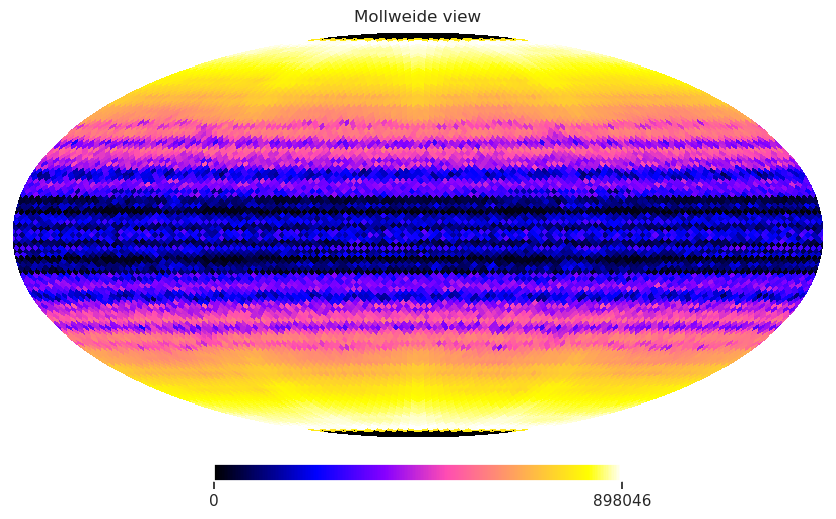

In [1126]:
hp.mollview(time,flip='geo',norm='hist',cmap='gnuplot2') # this map shows how many times the satellite goes 
# over a pixel.

In [1127]:
fomvals=np.linspace(0,55,55)

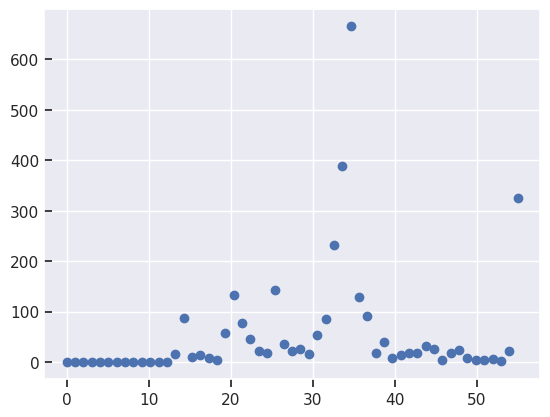

In [1128]:
plt.scatter(fomvals,(FOMtime1/3600))
plt.show()

In [1129]:
sum(FOMtime1)/3600

2964.05813937717

### Max uninterrupted RFI free time per day

In [1130]:
# This cell calculates maximum amount of uninterrupted >54 FOM time per day.
# in this case there is a max of 35.5 mins. (note that this is the max per day.)

In [1131]:
sunlit.shape

(366, 10000)

In [1132]:
np.shape(year_lat)[0]

366

In [1159]:
dailymax=[]
dailytotal=[]
for h in range(year_lat.shape[0]):
    oneslice=sunlit[h,:]
    count=0
    foms=[]
    for k in range(len(oneslice)):
        if oneslice[k-1]==oneslice[k]==False:
            pix=hp.ang2pix(nside,year_lon[h,k],year_lat[h,k],lonlat=True)
            foms.append(int(FOM_map[pix]))
            valz=[]
            for i in range(len(foms)-1):
                if foms[i+1]==foms[i]>=thresholdFOM:
                    count+=1
                else:
                    valz.append(count*(deltaT/60))
                    count=0
    dailymax.append(max(valz)) 
    dailytotal.append(sum(valz))



In [1148]:
dailymax[:100]

[13.537361653645833,
 14.833492024739583,
 11.809187825520834,
 13.39334716796875,
 14.401448567708334,
 11.953202311197916,
 14.6894775390625,
 12.9613037109375,
 13.537361653645833,
 15.841593424479166,
 11.953202311197916,
 13.681376139322916,
 13.105318196614583,
 13.39334716796875,
 14.6894775390625,
 11.809187825520834,
 13.681376139322916,
 13.105318196614583,
 13.39334716796875,
 15.697578938802083,
 11.809187825520834,
 14.6894775390625,
 12.9613037109375,
 13.39334716796875,
 15.697578938802083,
 12.097216796875,
 14.6894775390625,
 12.241231282552084,
 13.39334716796875,
 14.977506510416667,
 11.953202311197916,
 14.545463053385417,
 12.097216796875,
 13.39334716796875,
 14.401448567708334,
 13.105318196614583,
 14.545463053385417,
 11.809187825520834,
 13.537361653645833,
 12.9613037109375,
 13.39334716796875,
 15.697578938802083,
 11.809187825520834,
 13.969405110677084,
 12.9613037109375,
 13.537361653645833,
 15.697578938802083,
 12.241231282552084,
 14.6894775390625,
 1

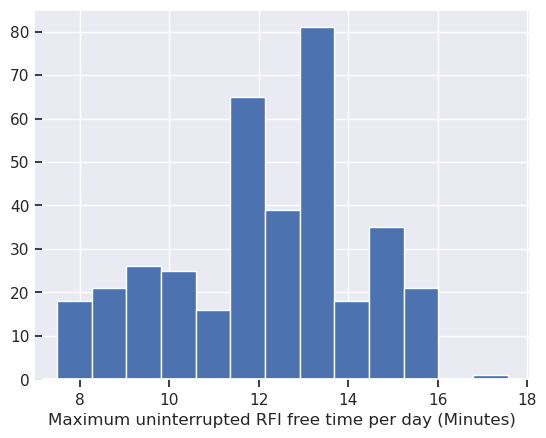

In [1135]:
from src2.FDrule import FDrule
plt.hist(dailymax,bins=FDrule(dailymax))
plt.xlabel('Maximum uninterrupted RFI free time per day (Minutes)')
# plt.savefig('/home/saurabhs/Documents/Yogen_starfire/SF_images/polar_unint.pdf',dpi=600,bbox_inches='tight')
plt.show()

In [1136]:
# RFI waterfall for one orbit
df=pd.read_csv('/home/saurabhs/Documents/Yogen_starfire/neworbit.csv')
Lon=df['Lon'].to_numpy()
Lat=df['Lat'].to_numpy()

In [1137]:
power_val=np.zeros((len(Lon),len(freq_range)))
pix=hp.ang2pix(nside,Lon,Lat,lonlat=True)
for idx,i in enumerate(pix):
    for j in range(len(freq_range)):
        power_val[idx,j]+=power_output[2,i,j]

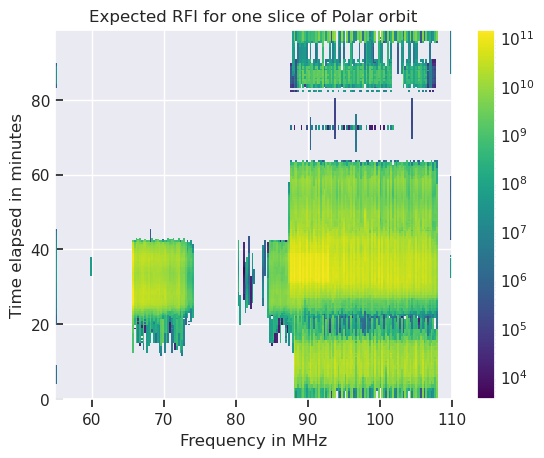

In [1138]:
x=(np.linspace(0,len(pix),len(Lon))*(98.73/1000))
y=freq_range
xx,yy=np.meshgrid(y,x)
plt.pcolormesh(xx,yy,power_val,norm='log',cmap='viridis',rasterized=True)
plt.colorbar()
plt.xlabel('Frequency in MHz')
plt.ylabel('Time elapsed in minutes')
plt.title('Expected RFI for one slice of Polar orbit')
plt.savefig('/home/saurabhs/Documents/Yogen_starfire/waterfall.pdf',dpi=600,bbox_inches='tight')
plt.show()

In [1139]:
FOMtime1[-1]/3600

324.88467848036026

## RFI assessment in equatorial orbit

### FOM map for AstroSAT (alt: 650km)

In [1087]:
FOM_map=np.zeros(hp.nside2npix(nside))
for i in range(len(FOM_map)):
	num_of_rfi_chan=len(freq_range[power_output[1,i,:]!=0])
	rfi_band=0.244*num_of_rfi_chan 
	usable_band=tot_band-rfi_band
	FOM_map[i]+=usable_band

In [1088]:
# open TLE archive
file=open('/home/saurabhs/Documents/Yogen_starfire/sat000040930.txt') #Astrosat data
content=file.read()
ts = load.timescale()
eph=load('de421.bsp')

In [1089]:
lineone=[]
linetwo=[]
num=478
days=[]
for i in range(479):
    line11=(content[((2*i)*70):((2*i)*70)+69])
    line22=(content[((2*i+1)*70):((2*i+1)*70)+69])
    sate=EarthSatellite(line11,line22,'Landsat7',ts)
#     print(sate)
    lineone.append(line11)
    linetwo.append(line22)
    year=sate.epoch.utc.year
    month=sate.epoch.utc.month
    day=sate.epoch.utc.day
    days.append(day)
    if year==2014.0:
        if month==1.0:
            if day==1.0:
                   break
    
    
uniq_idx=[]
for i in range(len(lineone)):
    if i>0:
        if days[i]!=days[i-1]:
            uniq_idx.append(i)
        
     

In [1090]:
len(days)

479

In [1091]:
# in the case of equitorial orbits, TLEs are not renewed as often since they don't perturb as much as 
# polar orbits. Hence there are TLEs every day with certain cases where there is one TLE for 2 days and so on.
# reps array records the gaps in TLE epochs. (if there is a 2 in reps, that means there is one TLE for two days.)

In [1092]:
reps=[1., 1., 2., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 2., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 2., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 2., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 3., 2., 2., 1., 2., 4., 1., 1., 2., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 2., 2.,
       1., 1., 2., 2., 1., 1., 1., 1., 1., 1., 2., 1., 4., 1., 1., 1., 2.,
       3., 1., 1., 1., 1., 1., 1., 1., 1., 2., 1., 1., 1., 2., 1., 1., 1.,
       1., 1., 1., 2., 1., 1., 1., 1., 2., 1., 1., 1., 2., 1., 1., 1., 1.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 2., 1., 1., 1., 1., 1., 2.,
       1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 2., 1.,
       1., 1., 1., 1., 1., 1., 2., 1., 1., 1., 1., 3., 1., 1., 3., 1., 1.,
       2., 1., 1., 1.,1.]

In [1093]:
reps=np.array(reps)

In [1094]:
subpoints=[]
sunlit=[]
t11=[]
for idx,i in enumerate(uniq_idx):
    if idx==0:
        line1=lineone[i]
        line2=linetwo[i]
        satellite = EarthSatellite(line1, line2, 'Landsat-8', ts)
        print(satellite)
        tz = pytz.timezone('UTC')
        st=satellite.epoch.utc
        dt=tz.fromutc(datetime(st.year,st.month,st.day,st.hour,st.minute,int(st.second)))
        t0 = ts.utc(dt)
        t1 = ts.utc(dt + relativedelta(hours=24))
        t11.append(t1)
        timescales = ts.linspace(t0,t1, 10000)

        geocentrics = satellite.at(timescales)
        sunlit.append(geocentrics.is_sunlit(eph))
        subpoints.append(wgs84.subpoint_of(geocentrics))
    else:
        line1=lineone[i]
        line2=linetwo[i]
        satellite = EarthSatellite(line1, line2, 'Landsat-8', ts)
        print(satellite)
        tz = pytz.timezone('UTC')
        st=t11[idx-1].utc
        dt=tz.fromutc(datetime(st.year,st.month,st.day,st.hour,st.minute,int(st.second)))
        t0 = ts.utc(dt)
        t1 = ts.utc(dt + relativedelta(hours=24*reps[idx])) # multiply 24 hrs with reps to account for skips.
        t11.append(t1)
        timescales = ts.linspace(t0,t1, 10000)

        geocentrics = satellite.at(timescales)
        sunlit.append(geocentrics.is_sunlit(eph))
        subpoints.append(wgs84.subpoint_of(geocentrics))

    

Landsat-8 catalog #40930 epoch 2016-01-02 02:33:11 UTC
Landsat-8 catalog #40930 epoch 2016-01-03 23:57:14 UTC
Landsat-8 catalog #40930 epoch 2016-01-05 11:37:34 UTC
Landsat-8 catalog #40930 epoch 2016-01-06 02:13:10 UTC
Landsat-8 catalog #40930 epoch 2016-01-07 02:32:29 UTC
Landsat-8 catalog #40930 epoch 2016-01-08 09:20:57 UTC
Landsat-8 catalog #40930 epoch 2016-01-09 08:02:59 UTC
Landsat-8 catalog #40930 epoch 2016-01-10 01:53:08 UTC
Landsat-8 catalog #40930 epoch 2016-01-11 03:49:45 UTC
Landsat-8 catalog #40930 epoch 2016-01-12 02:31:47 UTC
Landsat-8 catalog #40930 epoch 2016-01-13 07:42:58 UTC
Landsat-8 catalog #40930 epoch 2016-01-14 06:24:59 UTC
Landsat-8 catalog #40930 epoch 2016-01-15 08:21:35 UTC
Landsat-8 catalog #40930 epoch 2016-01-16 03:49:01 UTC
Landsat-8 catalog #40930 epoch 2016-01-17 04:08:19 UTC
Landsat-8 catalog #40930 epoch 2016-01-18 07:42:11 UTC
Landsat-8 catalog #40930 epoch 2016-01-19 04:46:55 UTC
Landsat-8 catalog #40930 epoch 2016-01-20 01:51:38 UTC
Landsat-8 

Landsat-8 catalog #40930 epoch 2016-06-13 01:44:42 UTC
Landsat-8 catalog #40930 epoch 2016-06-14 18:17:17 UTC
Landsat-8 catalog #40930 epoch 2016-06-15 04:01:05 UTC
Landsat-8 catalog #40930 epoch 2016-06-16 04:20:38 UTC
Landsat-8 catalog #40930 epoch 2016-06-17 01:25:34 UTC
Landsat-8 catalog #40930 epoch 2016-06-18 03:22:24 UTC
Landsat-8 catalog #40930 epoch 2016-06-19 03:41:57 UTC
Landsat-8 catalog #40930 epoch 2016-06-20 02:24:11 UTC
Landsat-8 catalog #40930 epoch 2016-06-21 04:21:01 UTC
Landsat-8 catalog #40930 epoch 2016-06-22 19:16:16 UTC
Landsat-8 catalog #40930 epoch 2016-06-23 01:45:29 UTC
Landsat-8 catalog #40930 epoch 2016-06-24 03:42:19 UTC
Landsat-8 catalog #40930 epoch 2016-06-25 04:01:51 UTC
Landsat-8 catalog #40930 epoch 2016-06-26 01:06:47 UTC
Landsat-8 catalog #40930 epoch 2016-06-27 01:26:19 UTC
Landsat-8 catalog #40930 epoch 2016-06-28 00:08:34 UTC
Landsat-8 catalog #40930 epoch 2016-06-29 02:05:24 UTC
Landsat-8 catalog #40930 epoch 2016-06-30 00:47:38 UTC
Landsat-8 

In [1095]:
year_lon=[]
year_lat=[]
for i in range(len(subpoints)):
    year_lon.append(subpoints[i].longitude.degrees)
    year_lat.append(subpoints[i].latitude.degrees)

In [1096]:
sunlit=np.array(sunlit)

In [1097]:
year_lon=np.array(year_lon)
year_lat=np.array(year_lat)

In [1098]:
FOMtime=np.zeros(55)
for i in range(len(year_lat)):
    for j in range(len(year_lat[0])):
        orbpix=hp.ang2pix(nside,year_lon[i,j],year_lat[i,j],lonlat=True)
        fomval=int(FOM_map[orbpix])
        if sunlit[i,j]==True:
            FOMtime[fomval]+=0
        else:
            FOMtime[fomval]+=deltaT

In [1099]:
fomvals=np.linspace(0,55,55)

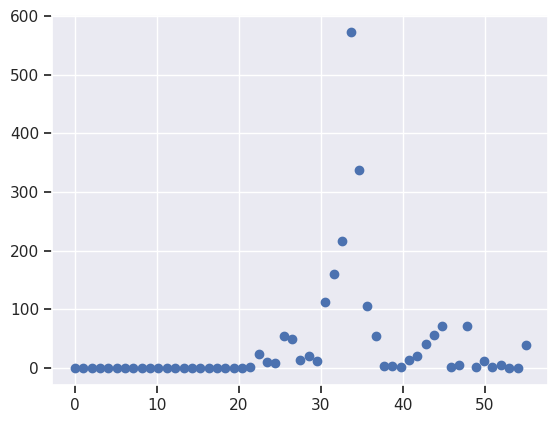

In [1100]:
plt.scatter(fomvals,(FOMtime/3600))
plt.show()

In [1101]:
FOMtime[-1]/3600

39.275150485568574

In [1102]:
dailymax=[]
dailytotal=[]
for h in range(year_lat.shape[0]):
    oneslice=sunlit[h,:]
    count=0
    foms=[]
    for k in range(len(oneslice)):
        if oneslice[k-1]==oneslice[k]==False:
            pix=hp.ang2pix(nside,year_lon[h,k],year_lat[h,k],lonlat=True)
            foms.append(int(FOM_map[pix]))
            valz=[]
            for i in range(len(foms)-1):
                if foms[i+1]==foms[i]==thresholdFOM:
                    count+=1
                else:
                    valz.append(count*(deltaT/60))
                    count=0
    dailymax.append(max(valz))            
    dailytotal.append(sum(valz))


In [1109]:
(np.mean(dailymax)*365)/60

19.170238439858355

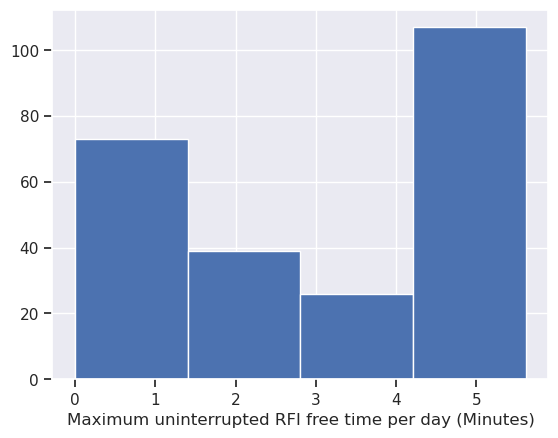

In [1103]:
plt.hist(dailymax,bins=FDrule(dailymax))
plt.xlabel('Maximum uninterrupted RFI free time per day (Minutes)')
# plt.savefig('/home/saurabhs/Documents/Yogen_starfire/SF_images/equi_unint.pdf',dpi=600,bbox_inches='tight')

plt.show()

In [517]:
OWFOM=np.zeros(hp.nside2npix(nside))
time=np.zeros(np.shape(OWFOM))
for i in year_lat:
    for j in year_lon:
        pix=hp.ang2pix(nside,j,i,lonlat=True)
        OWFOM[pix]+=FOM_map[pix]
        time[pix]+=1
        

/tmp/ipykernel_847166/4071895060.py:1: RuntimeWarning: invalid value encountered in divide
  hp.mollview(OWFOM/time,flip='geo',norm='hist')


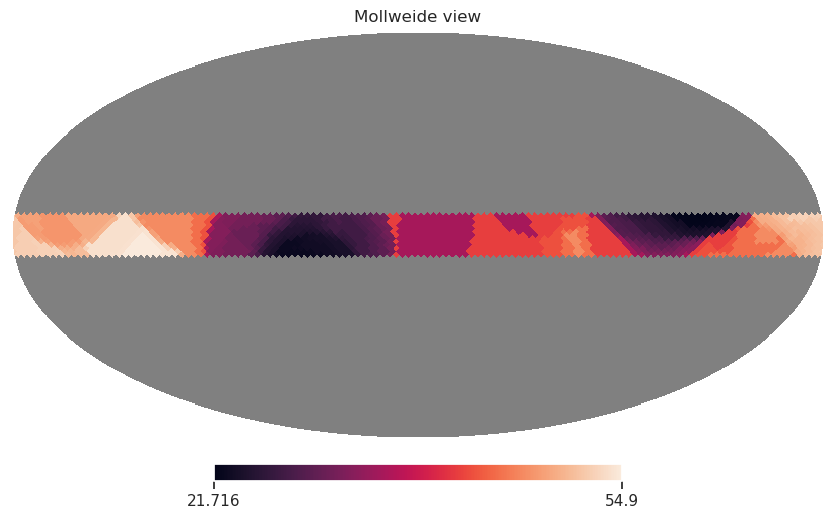

In [518]:
hp.mollview(OWFOM/time,flip='geo',norm='hist')

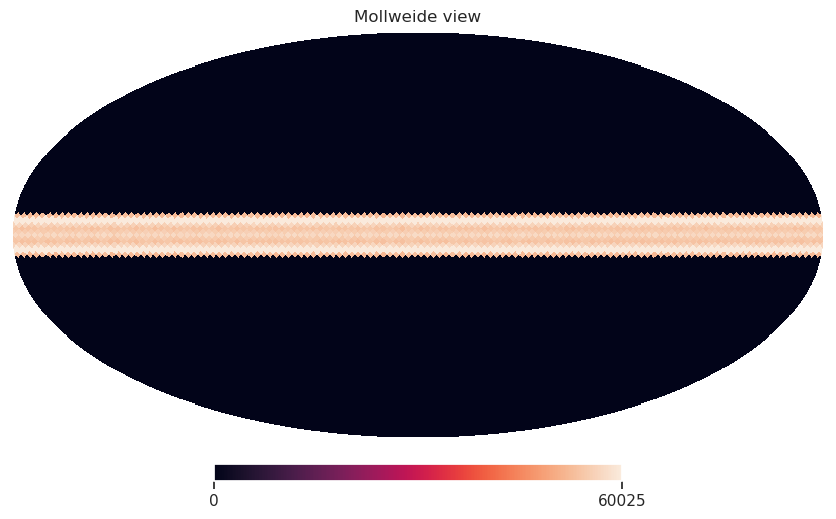

In [519]:
hp.mollview(time,flip='geo',norm='hist')

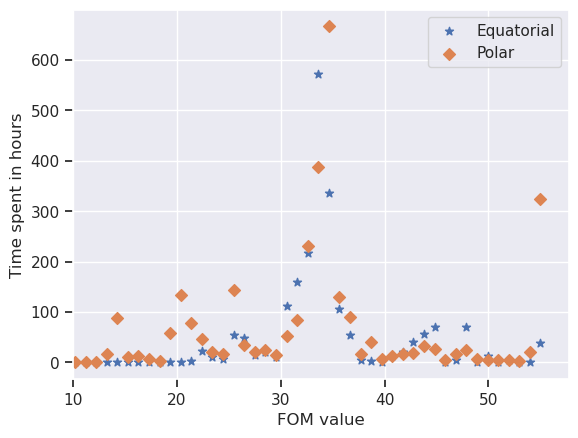

In [521]:
# compare the two orbits:
plt.scatter(fomvals,FOMtime/3600,label='Equatorial',marker='*')
plt.scatter(fomvals,FOMtime1/3600,label='Polar',marker='D')
plt.ylabel('Time spent in hours')
plt.xlabel('FOM value')
plt.xlim(left=10)
plt.legend()
# plt.savefig('/home/saurabhs/Documents/Yogen_starfire/SF_images/orbit_timecompare.pdf',dpi=600,bbox_inches='tight')
plt.show()

## ISS orbit trial

### FOM map for ISS (alt:410km)

In [579]:
FOM_map=np.zeros(hp.nside2npix(nside))
for i in range(len(FOM_map)):
	num_of_rfi_chan=len(freq_range[power_output[0,i,:]!=0])
	rfi_band=0.244*num_of_rfi_chan 
	usable_band=tot_band-rfi_band
	FOM_map[i]+=usable_band

In [580]:
# open TLE archive
file=open('/home/saurabhs/Documents/Yogen_starfire/zarya.txt')
content=file.read()
ts = load.timescale()
eph=load('de421.bsp')

In [581]:
lineone=[]
linetwo=[]
num=2000
year=np.zeros(num)
month=np.zeros(num)
days=np.zeros((num))
hour=np.zeros((num))
minute=np.zeros((num))
second=np.zeros((num))
for i in range(2000):
    line11=(content[((2*i)*70):((2*i)*70)+69])
    line22=(content[((2*i+1)*70):((2*i+1)*70)+69])
    sate=EarthSatellite(line11,line22,'Landsat7',ts)
#     print(sate)
    lineone.append(line11)
    linetwo.append(line22)
    year=sate.epoch.utc.year
    month=sate.epoch.utc.month
    day=sate.epoch.utc.day
    days[i]+=day
    if year==1999.0:
        if month==11.0:
            if day==20.0:
                   break
    
    
    

In [582]:
uniq_idx=[]
for i in range(len(lineone)):
    if i>0:
        if days[i]!=days[i-1]:
            uniq_idx.append(i)
        
   

In [583]:
subpoints=[]
sunlit=[]
t11=[]
for idx,i in enumerate(uniq_idx):
    if idx==0:
        line1=lineone[i]
        line2=linetwo[i]
        satellite = EarthSatellite(line1, line2, 'Landsat-8', ts)
        print(satellite)
        tz = pytz.timezone('UTC')
        st=satellite.epoch.utc
        dt=tz.fromutc(datetime(st.year,st.month,st.day,st.hour,st.minute,int(st.second)))
        t0 = ts.utc(dt)
        t1 = ts.utc(dt + relativedelta(hours=24))
        t11.append(t1)
        timescales = ts.linspace(t0,t1, 10000)

        geocentrics = satellite.at(timescales)
        sunlit.append(geocentrics.is_sunlit(eph))
        subpoints.append(wgs84.subpoint_of(geocentrics))
    else:
        line1=lineone[i]
        line2=linetwo[i]
        satellite = EarthSatellite(line1, line2, 'Landsat-8', ts)
        print(satellite)
        tz = pytz.timezone('UTC')
        st=t11[idx-1].utc
        dt=tz.fromutc(datetime(st.year,st.month,st.day,st.hour,st.minute,int(st.second)))
        t0 = ts.utc(dt)
        t1 = ts.utc(dt + relativedelta(hours=24))
        t11.append(t1)
        timescales = ts.linspace(t0,t1, 10000)

        geocentrics = satellite.at(timescales)
        sunlit.append(geocentrics.is_sunlit(eph))
        subpoints.append(wgs84.subpoint_of(geocentrics))

    

Landsat-8 catalog #25544 epoch 1998-11-21 00:24:42 UTC
Landsat-8 catalog #25544 epoch 1998-11-22 03:27:47 UTC
Landsat-8 catalog #25544 epoch 1998-11-23 03:33:31 UTC
Landsat-8 catalog #25544 epoch 1998-11-24 02:22:53 UTC
Landsat-8 catalog #25544 epoch 1998-11-25 02:57:09 UTC
Landsat-8 catalog #25544 epoch 1998-11-26 03:33:53 UTC
Landsat-8 catalog #25544 epoch 1998-11-27 04:10:35 UTC
Landsat-8 catalog #25544 epoch 1998-11-28 03:14:59 UTC
Landsat-8 catalog #25544 epoch 1998-11-29 00:47:03 UTC
Landsat-8 catalog #25544 epoch 1998-11-30 01:23:39 UTC
Landsat-8 catalog #25544 epoch 1998-12-01 02:00:12 UTC
Landsat-8 catalog #25544 epoch 1998-12-02 04:08:58 UTC
Landsat-8 catalog #25544 epoch 1998-12-03 01:40:52 UTC
Landsat-8 catalog #25544 epoch 1998-12-04 03:49:33 UTC
Landsat-8 catalog #25544 epoch 1998-12-05 04:25:54 UTC
Landsat-8 catalog #25544 epoch 1998-12-06 03:29:56 UTC
Landsat-8 catalog #25544 epoch 1998-12-07 04:06:13 UTC
Landsat-8 catalog #25544 epoch 1998-12-08 04:42:23 UTC
Landsat-8 

Landsat-8 catalog #25544 epoch 1999-04-19 03:42:42 UTC
Landsat-8 catalog #25544 epoch 1999-04-20 02:46:19 UTC
Landsat-8 catalog #25544 epoch 1999-04-21 01:49:53 UTC
Landsat-8 catalog #25544 epoch 1999-04-22 03:57:53 UTC
Landsat-8 catalog #25544 epoch 1999-04-23 03:01:23 UTC
Landsat-8 catalog #25544 epoch 1999-04-24 03:37:06 UTC
Landsat-8 catalog #25544 epoch 1999-04-25 02:40:34 UTC
Landsat-8 catalog #25544 epoch 1999-04-26 03:16:13 UTC
Landsat-8 catalog #25544 epoch 1999-04-27 03:51:52 UTC
Landsat-8 catalog #25544 epoch 1999-04-28 04:27:29 UTC
Landsat-8 catalog #25544 epoch 1999-04-29 03:30:50 UTC
Landsat-8 catalog #25544 epoch 1999-04-30 04:06:23 UTC
Landsat-8 catalog #25544 epoch 1999-05-01 03:09:40 UTC
Landsat-8 catalog #25544 epoch 1999-05-02 03:45:09 UTC
Landsat-8 catalog #25544 epoch 1999-05-03 02:48:22 UTC
Landsat-8 catalog #25544 epoch 1999-05-04 00:19:22 UTC
Landsat-8 catalog #25544 epoch 1999-05-05 03:59:09 UTC
Landsat-8 catalog #25544 epoch 1999-05-06 03:02:17 UTC
Landsat-8 

Landsat-8 catalog #25544 epoch 1999-09-15 00:50:47 UTC
Landsat-8 catalog #25544 epoch 1999-09-16 06:00:21 UTC
Landsat-8 catalog #25544 epoch 1999-09-17 00:25:19 UTC
Landsat-8 catalog #25544 epoch 1999-09-18 02:30:39 UTC
Landsat-8 catalog #25544 epoch 1999-09-19 03:03:51 UTC
Landsat-8 catalog #25544 epoch 1999-09-20 02:04:56 UTC
Landsat-8 catalog #25544 epoch 1999-09-21 02:38:03 UTC
Landsat-8 catalog #25544 epoch 1999-09-22 03:11:07 UTC
Landsat-8 catalog #25544 epoch 1999-09-23 03:44:07 UTC
Landsat-8 catalog #25544 epoch 1999-09-24 02:45:00 UTC
Landsat-8 catalog #25544 epoch 1999-09-25 00:13:47 UTC
Landsat-8 catalog #25544 epoch 1999-09-26 02:18:42 UTC
Landsat-8 catalog #25544 epoch 1999-09-27 04:23:33 UTC
Landsat-8 catalog #25544 epoch 1999-09-28 01:52:13 UTC
Landsat-8 catalog #25544 epoch 1999-09-29 03:56:57 UTC
Landsat-8 catalog #25544 epoch 1999-09-30 02:57:33 UTC
Landsat-8 catalog #25544 epoch 1999-10-01 03:30:08 UTC
Landsat-8 catalog #25544 epoch 1999-10-02 04:02:41 UTC
Landsat-8 

In [586]:
year_lon=[]
year_lat=[]
for i in range(len(subpoints)):
    year_lon.append(subpoints[i].longitude.degrees)
    year_lat.append(subpoints[i].latitude.degrees)

In [587]:
sunlit=np.array(sunlit)
year_lon=np.array(year_lon)
year_lat=np.array(year_lat)

In [588]:
FOMtime1=np.zeros(55)
for i in range(len(year_lat)):
    for j in range(len(year_lat[0])):
        orbpix=hp.ang2pix(nside,year_lon[i,j],year_lat[i,j],lonlat=True)
        fomval=int(FOM_map[orbpix])
        if sunlit[i,j]==True:
            FOMtime1[fomval]+=0
        else:
            FOMtime1[fomval]+=deltaT

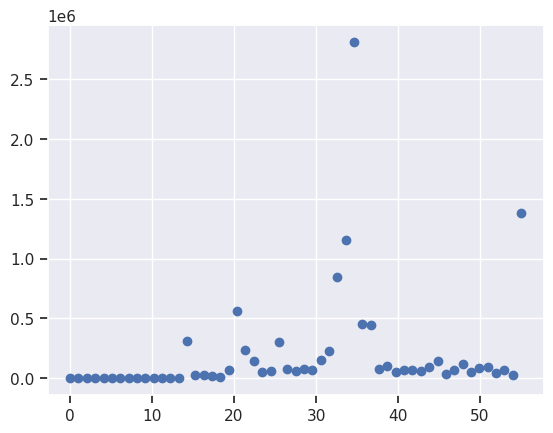

In [589]:
plt.scatter(fomvals,FOMtime1)
plt.show()

In [590]:
FOMtime1[-1]/3600

384.49227410210506

In [591]:
OWFOM=np.zeros(hp.nside2npix(nside))
time=np.zeros(np.shape(OWFOM))
for i in year_lat:
    for j in year_lon:
        pix=hp.ang2pix(nside,j,i,lonlat=True)
        OWFOM[pix]+=FOM_map[pix]
        time[pix]+=1
        

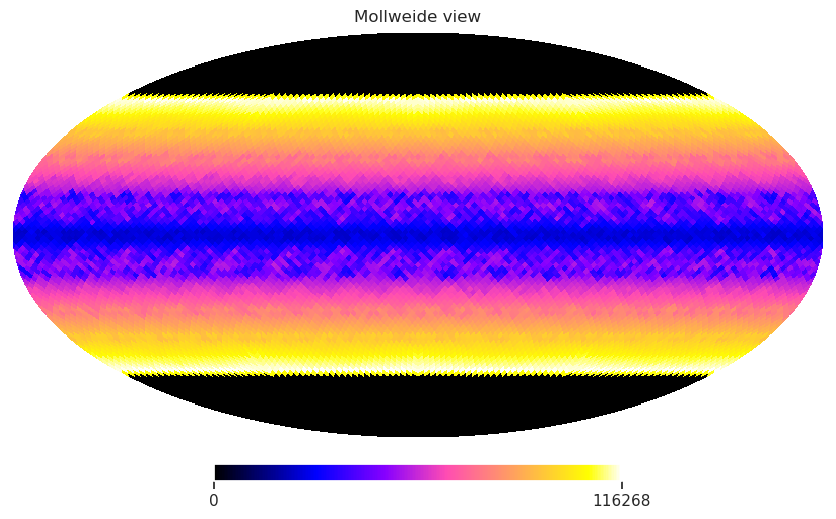

In [592]:
hp.mollview(time,flip='geo',norm='hist',cmap='gnuplot2')
plt.show()

## one day slice 

In [593]:
point=[]
for i in range(len(year_lat)): # i is one day
    foms=[]
    for j in range(len(year_lat[0])): # j is a point in a day of OP
        if sunlit[i,j]==False:
            orbpix=hp.ang2pix(nside,year_lon[i,j],year_lat[i,j],lonlat=True)
            fomval=int(FOM_map[orbpix])
            foms.append(fomval) # record FOM at each point of OP for one day
            count=0 # set count to 0
            valz=[] # list to which uninterrupted 54 FOM times will be appended.
            for k in range(len(foms)): # loop through each fom val per day (10000 vals)
                if foms[k]>50:
                    count+=1 # count gets +1 if FOM is 54.
                else:
                    valz.append(count*(deltaT/60)) # if FOM changes, it appends uninterrupted time and resets count
                    count=0                        # to 0.
    print(f'There is a maximum of {max(valz)} minutes of uninterrupted 55FOM on this day {sum(valz)}') # print max uninterrupted time.

There is a maximum of 13.39334716796875 minutes of uninterrupted 55FOM on this day 94.3294881184896
There is a maximum of 11.809187825520834 minutes of uninterrupted 55FOM on this day 62.07024332682291
There is a maximum of 0.43204345703125 minutes of uninterrupted 55FOM on this day 0.43204345703125
There is a maximum of 0.43204345703125 minutes of uninterrupted 55FOM on this day 0.43204345703125
There is a maximum of 8.20882568359375 minutes of uninterrupted 55FOM on this day 11.233129882812499
There is a maximum of 13.249332682291666 minutes of uninterrupted 55FOM on this day 59.33396809895833
There is a maximum of 15.841593424479166 minutes of uninterrupted 55FOM on this day 74.59950358072915
There is a maximum of 16.4176513671875 minutes of uninterrupted 55FOM on this day 73.15935872395833
There is a maximum of 16.561665852864582 minutes of uninterrupted 55FOM on this day 71.28717041015625
There is a maximum of 16.129622395833334 minutes of uninterrupted 55FOM on this day 75.175561

KeyboardInterrupt: 

## Terra orbit

In [800]:
# open TLE archive data
file=open('../TerraSAR.txt') # this file contains multiple TLEs everyday for mulitple years
content=file.read()
ts = load.timescale()
eph=load('de421.bsp') # solar system ephemeris to obtain 'sunlit' parameter. (used later)

In [801]:
lineone=[]
linetwo=[]
num=2000
days=np.zeros((num))
for i in range(2000):
    line11=(content[((2*i)*70):((2*i)*70)+69]) # first line of all TLEs
    line22=(content[((2*i+1)*70):((2*i+1)*70)+69]) # second line of all TLEs
    sate=EarthSatellite(line11,line22,'Landsat7',ts) # call EarthSatellite function (skyfield library) 
                                                     # To access TLE epochs in normal date time format.
#     print(sate)
    lineone.append(line11)
    linetwo.append(line22)
    year=sate.epoch.utc.year
    month=sate.epoch.utc.month
    day=sate.epoch.utc.day
    days[i]+=day
    if year==2000.0:
        if month==12.0:
            if day==18.0:
                   break # Stop after appending one year's worth of TLEs 
                         # Each day still contains multiple TLEs (just one per day is required.)
                         # Next cell gets one TLE per day.
    
    
    

In [802]:
uniq_idx=[]
for i in range(len(lineone)):
    if i>0:
        if days[i]!=days[i-1]:
            uniq_idx.append(i) # obtained indices such that there's one TLE per day
        
   

In [803]:
subpoints=[] # This will contain ground track coordinates
sunlit=[] # Boolean array of satellite is sunlit or not
t11=[] 
for idx,i in enumerate(uniq_idx):
    if idx==0:
        line1=lineone[i] # first line of TLE on day 1 of OP
        line2=linetwo[i] # second line
        satellite = EarthSatellite(line1, line2, 'Landsat-8', ts) # call EarthSatellite function to do OP
        print(satellite)
        tz = pytz.timezone('UTC') # define a standard timezone (UTC in this case)
        st=satellite.epoch.utc # starting point of OP is the epoch of the TLE for day 1 of OP
        dt=tz.fromutc(datetime(st.year,st.month,st.day,st.hour,st.minute,int(st.second))) 
        t0 = ts.utc(dt)  # starting point of OP                                                             
        t1 = ts.utc(dt + relativedelta(hours=24)) # end point of OP (1 day propagation)
        t11.append(t1) # record the end point of OP of that day. Use this as starting point for next day's OP.
        timescales = ts.linspace(t0,t1, 10000) # define a time linspace (skyfield lib function) with time
        # resolution of 10000 points. (10000 points in 24 hours) 

        geocentrics = satellite.at(timescales) # Note geocentrics (state vectors with geocentric reference frame) at each point (10000 points)
        sunlit.append(geocentrics.is_sunlit(eph)) # record sunlit Boolean
        subpoints.append(wgs84.subpoint_of(geocentrics)) # convert state vectors to wgs84 (lat,lon) to get ground trace.
    else: # for days after day 0:
        line1=lineone[i]
        line2=linetwo[i]
        satellite = EarthSatellite(line1, line2, 'Landsat-8', ts)
        print(satellite)
        tz = pytz.timezone('UTC')
        st=t11[idx-1].utc # we use the end point of previous day's OP as starting point here.
        dt=tz.fromutc(datetime(st.year,st.month,st.day,st.hour,st.minute,int(st.second)))
        t0 = ts.utc(dt)
        t1 = ts.utc(dt + relativedelta(hours=24))
        t11.append(t1)
        timescales = ts.linspace(t0,t1, 10000)

        geocentrics = satellite.at(timescales)
        sunlit.append(geocentrics.is_sunlit(eph))
        subpoints.append(wgs84.subpoint_of(geocentrics))

    

Landsat-8 catalog #31698 epoch 2008-01-02 04:33:52 UTC
Landsat-8 catalog #31698 epoch 2008-01-03 06:08:49 UTC
Landsat-8 catalog #31698 epoch 2008-01-04 05:16:47 UTC
Landsat-8 catalog #31698 epoch 2008-01-05 01:55:43 UTC
Landsat-8 catalog #31698 epoch 2008-01-06 03:09:53 UTC
Landsat-8 catalog #31698 epoch 2008-01-07 11:09:29 UTC
Landsat-8 catalog #31698 epoch 2008-01-08 13:59:27 UTC
Landsat-8 catalog #31698 epoch 2008-01-09 03:50:55 UTC
Landsat-8 catalog #31698 epoch 2008-01-10 02:04:02 UTC
Landsat-8 catalog #31698 epoch 2008-01-11 03:23:29 UTC
Landsat-8 catalog #31698 epoch 2008-01-12 06:06:30 UTC
Landsat-8 catalog #31698 epoch 2008-01-13 12:34:34 UTC
Landsat-8 catalog #31698 epoch 2008-01-14 08:54:51 UTC
Landsat-8 catalog #31698 epoch 2008-01-15 03:42:11 UTC
Landsat-8 catalog #31698 epoch 2008-01-16 05:32:56 UTC
Landsat-8 catalog #31698 epoch 2008-01-17 03:07:53 UTC
Landsat-8 catalog #31698 epoch 2008-01-18 02:52:22 UTC
Landsat-8 catalog #31698 epoch 2008-01-19 01:02:57 UTC
Landsat-8 

Landsat-8 catalog #31698 epoch 2008-05-30 04:09:37 UTC
Landsat-8 catalog #31698 epoch 2008-05-31 05:25:02 UTC
Landsat-8 catalog #31698 epoch 2008-06-01 03:33:53 UTC
Landsat-8 catalog #31698 epoch 2008-06-02 03:15:47 UTC
Landsat-8 catalog #31698 epoch 2008-06-03 03:01:23 UTC
Landsat-8 catalog #31698 epoch 2008-06-04 04:18:03 UTC
Landsat-8 catalog #31698 epoch 2008-06-05 02:29:50 UTC
Landsat-8 catalog #31698 epoch 2008-06-06 05:49:33 UTC
Landsat-8 catalog #31698 epoch 2008-06-07 01:55:35 UTC
Landsat-8 catalog #31698 epoch 2008-06-08 03:08:11 UTC
Landsat-8 catalog #31698 epoch 2008-06-09 04:42:42 UTC
Landsat-8 catalog #31698 epoch 2008-06-10 01:01:24 UTC
Landsat-8 catalog #31698 epoch 2008-06-11 02:21:21 UTC
Landsat-8 catalog #31698 epoch 2008-06-12 03:33:46 UTC
Landsat-8 catalog #31698 epoch 2008-06-13 05:08:44 UTC
Landsat-8 catalog #31698 epoch 2008-06-14 04:51:23 UTC
Landsat-8 catalog #31698 epoch 2008-06-15 01:12:01 UTC
Landsat-8 catalog #31698 epoch 2008-06-16 06:06:18 UTC
Landsat-8 

Landsat-8 catalog #31698 epoch 2008-10-26 02:15:58 UTC
Landsat-8 catalog #31698 epoch 2008-10-27 02:09:36 UTC
Landsat-8 catalog #31698 epoch 2008-10-28 00:19:13 UTC
Landsat-8 catalog #31698 epoch 2008-10-29 03:08:45 UTC
Landsat-8 catalog #31698 epoch 2008-10-30 04:26:38 UTC
Landsat-8 catalog #31698 epoch 2008-10-31 02:34:58 UTC
Landsat-8 catalog #31698 epoch 2008-11-01 02:19:04 UTC
Landsat-8 catalog #31698 epoch 2008-11-02 02:01:35 UTC
Landsat-8 catalog #31698 epoch 2008-11-03 03:15:54 UTC
Landsat-8 catalog #31698 epoch 2008-11-04 02:55:25 UTC
Landsat-8 catalog #31698 epoch 2008-11-05 01:12:07 UTC
Landsat-8 catalog #31698 epoch 2008-11-06 04:01:16 UTC
Landsat-8 catalog #31698 epoch 2008-11-07 02:09:57 UTC
Landsat-8 catalog #31698 epoch 2008-11-08 03:24:49 UTC
Landsat-8 catalog #31698 epoch 2008-11-09 03:08:13 UTC
Landsat-8 catalog #31698 epoch 2008-11-10 02:41:25 UTC
Landsat-8 catalog #31698 epoch 2008-11-11 04:09:50 UTC
Landsat-8 catalog #31698 epoch 2008-11-12 02:21:27 UTC
Landsat-8 

In [822]:
# ground trace (subpoints list) isn't in lat lon format yet. This cell does that.
year_lon=[]
year_lat=[]
for i in range(len(subpoints)):
    year_lon.append(subpoints[i].longitude.degrees)
    year_lat.append(subpoints[i].latitude.degrees)

In [823]:
sunlit=np.array(sunlit)
year_lon=np.array(year_lon)
year_lat=np.array(year_lat)
# now year_lat and year_lon have shape of 365,10000. This means there are 10000 ground track coords per day.

In [824]:
year_lon.shape

(367, 10000)

In [825]:
year_lon=year_lon[:366,:10000]
year_lat=year_lat[:366,:10000]

In [826]:
year_lon.shape

(366, 10000)

In [832]:
# this cell calculates FOM of each pixel over an altitude of 705 km
FOM_map=np.zeros(hp.nside2npix(nside))
for i in range(len(FOM_map)):
	num_of_rfi_chan=len(freq_range[power_output[1,i,:]!=0])
	rfi_band=0.244*num_of_rfi_chan 
	usable_band=tot_band-rfi_band
	FOM_map[i]+=usable_band

In [833]:
FOMtime1=np.zeros(55) # define FOM bins of width 1 MHz 
for i in range(len(year_lat)): # i is a day of OP
    for j in range(len(year_lat[0])): # j is each ground track coord of that sliced day. (10000 points)
        orbpix=hp.ang2pix(nside,year_lon[i,j],year_lat[i,j],lonlat=True) # get pixel of coord
        fomval=int(FOM_map[orbpix]) # obtain FOM value in integer format
        if sunlit[i,j]==True: 
            FOMtime1[fomval]+=0 # Does not count the FOM if it is sunlit.
        else:
            FOMtime1[fomval]+=deltaT # Adds deltaT if the point is not sunlit, as it spends deltaT time at that
                                     # point.

In [836]:
FOMtime1[-1]/3600

273.86034620496963

In [835]:
for i in range(len(year_lat)): # i is one day
    foms=[]
    for j in range(len(year_lat[0])): # j is a point in a day of OP
        if sunlit[i,j]==False:
            orbpix=hp.ang2pix(nside,year_lon[i,j],year_lat[i,j],lonlat=True)
            fomval=int(FOM_map[orbpix])
            foms.append(fomval) # record FOM at each point of OP for one day
            count=0 # set count to 0
            valz=[] # list to which uninterrupted 54 FOM times will be appended.
            for k in range(len(foms)): # loop through each fom val per day (10000 vals)
                if foms[k]>50:
                    count+=1 # count gets +1 if FOM is 54.
                else:
                    valz.append(count*(deltaT/60)) # if FOM changes, it appends uninterrupted time and resets count
                    count=0                        # to 0.
    print(f'There is a maximum of {max(valz)} minutes of uninterrupted 55FOM on this day {sum(valz)}') # print max uninterrupted time.

ValueError: max() arg is an empty sequence

In [ ]:
sunlit[10,:]

In [837]:
for i in range(len(year_lat)): # i is one day
    foms=[]
    for j in range(len(year_lat[0])): # j is a point in a day of OP
            orbpix=hp.ang2pix(nside,year_lon[i,j],year_lat[i,j],lonlat=True)
            fomval=int(FOM_map[orbpix])
            foms.append(fomval) # record FOM at each point of OP for one day
            count=0 # set count to 0
            valz=[] # list to which uninterrupted 54 FOM times will be appended.
            for k in range(len(foms)): # loop through each fom val per day (10000 vals)
                if foms[k]>50:
                    count+=1 # count gets +1 if FOM is 54.
                else:
                    valz.append(count*(deltaT/60)) # if FOM changes, it appends uninterrupted time and resets count
                    count=0                        # to 0.
    print(f'There is a maximum of {max(valz)} minutes of uninterrupted 55FOM on this day {sum(valz)}') # print max uninterrupted time.

There is a maximum of 35.283548990885414 minutes of uninterrupted 55FOM on this day 263.11446533203116
There is a maximum of 35.4275634765625 minutes of uninterrupted 55FOM on this day 247.70491536458331
There is a maximum of 34.99552001953125 minutes of uninterrupted 55FOM on this day 260.3781901041667


KeyboardInterrupt: 

## RFI temp heatmap

In [741]:
freq_range[144]

90.13599999999997

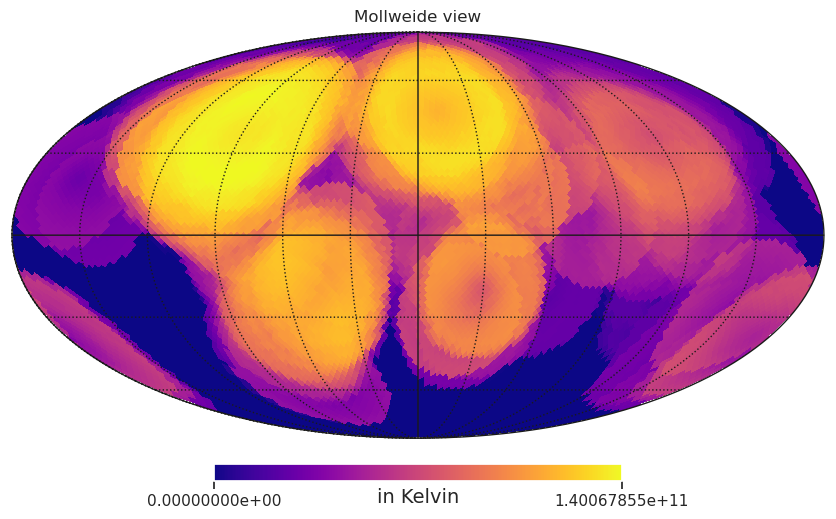

In [739]:
test_plot1 = np.zeros(hp.nside2npix(nside)) 
test_plot1[0:np.size(power_output[2,:,150])] = power_output[2,:,144]
hp.mollview(test_plot1,cmap='plasma',unit="in Kelvin",norm='hist',flip='geo',format= '%.8e')#,cb_orientation="vertical",title="Mollweide projection for Received power in Kelvin at 88.9MHz",flip='g')
hp.graticule()
# plt.savefig('/home/saurabhs/Documents/Yogen_starfire/SF_images/RFI_latestHM.pdf')
plt.show()

In [107]:
powercube_df=pd.DataFrame(power_output[0,:,:])
# powercube_df.to_csv('/home/saurabhs/Documents/Yogen_starfire/RFInosynth_cubeLeo')

## RFI power recieved in different orbits

## Polar orbit RFI waterfall plots

In [108]:
# Set time resolution
# Average velocity of satellite in LEO is ~8 km/s
time_res=10000
polat=np.linspace(-90,90,time_res)
polon=np.zeros(len(polat))
# Define trajectory pixels
pol_traj_pix=hp.ang2pix(nside,polon,polat,lonlat=True)


In [109]:
# waterfall plots of pixel vs frequency and power as the weight
x=freq_range
y=polat
xx,yy=np.meshgrid(x,y)
power_val=np.zeros((len(pol_traj_pix),len(x)))
for i in range(len(x)):
    for index,j in enumerate(pol_traj_pix):
        power_val[index,i]+=power_output[0,j,i]


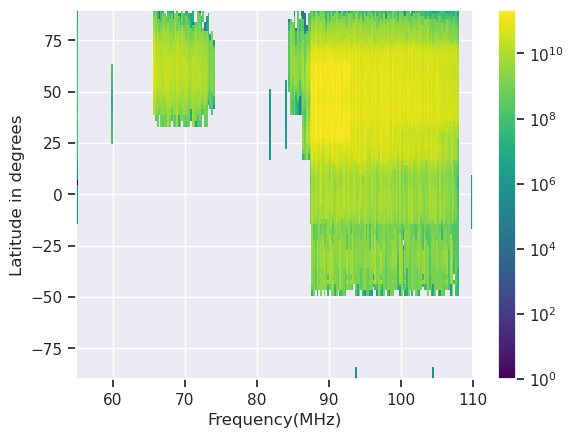

In [110]:
plt.pcolormesh(xx,yy,power_val,cmap='viridis',norm='log',vmin=1,rasterized=True)
plt.xlabel('Frequency(MHz)')
plt.ylabel('Latitude in degrees')
plt.colorbar()
# plt.savefig('/home/saurabhs/Documents/Yogen_starfire/SF_images/polar_waterfall.pdf',dpi=600,bbox_inches='tight')
plt.show()

## Equatorial orbit RFI waterfall plots

In [111]:
# Set time resolution
# Average velocity of satellite in LEO is ~8 km/s
time_res=10000
eqlon=np.linspace(-180,180,time_res)
eqlat=np.zeros(len(eqlon))

# Define trajectory pixels
eq_traj_pix=hp.ang2pix(nside,eqlon,eqlat,lonlat=True)


In [112]:
# waterfall plots of pixel vs frequency and power as the weight
x=freq_range
y=eqlon
xx,yy=np.meshgrid(x,y)
power_val=np.zeros((len(eq_traj_pix),len(x)))
for i in range(len(x)):
    for index,j in enumerate(eq_traj_pix):
        power_val[index,i]+=power_output[0,j,i]


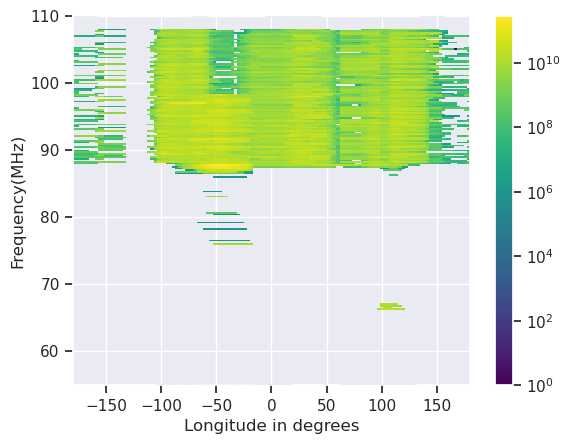

In [113]:
plt.pcolormesh(yy,xx,power_val,cmap='viridis',norm='log',vmin=1e0,rasterized=True)
plt.colorbar()
plt.xlabel('Longitude in degrees')
plt.ylabel('Frequency(MHz)')
# plt.savefig('/home/saurabhs/Documents/Yogen_starfire/SF_images/equisynth_waterfall_1.pdf',dpi=600,bbox_inches='tight')
plt.show()

In [114]:
print(yy.shape,xx.shape,power_val.shape)

# plt.imshow(np.array([yy,xx,power_val]))

(10000, 226) (10000, 226) (10000, 226)


In [115]:
def shapecheck(lon,lat,name):
    checkpix=hp.ang2pix(nside,lon,lat,lonlat=True)
    checkmap=np.zeros(hp.nside2npix(nside))
    for pi in checkpix:
        checkmap[pi]+=1
    checkmap=np.where(checkmap != 0, 1, 0)
    return hp.mollview(checkmap,flip='geo',title=name,cmap='inferno')
    


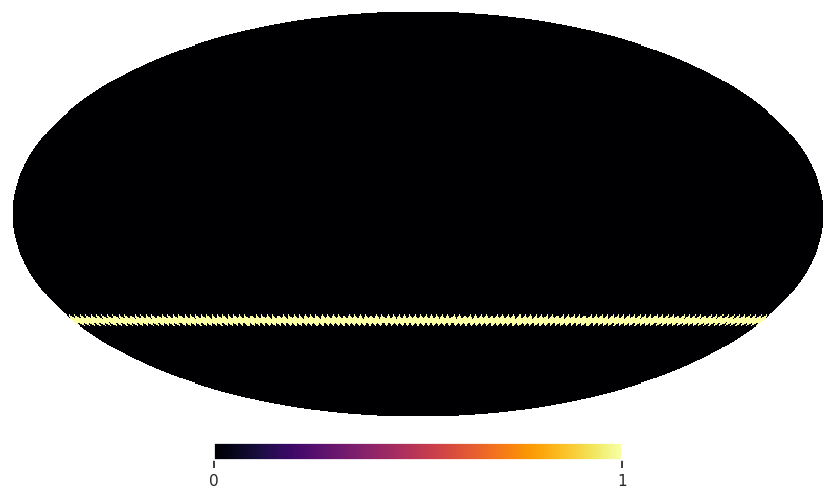

In [116]:
eqlat=np.full((np.shape(eqlon)),-40)

shapecheck(eqlon,eqlat,'')

## RFI freq summed power per pixel

### Polar orbit 

In [121]:
#GS for LEO
GS=np.zeros(len(freq_range))
for i in range(len(GS)):
    GS[i]+=(sum(power_output[0,:,i])/npix)

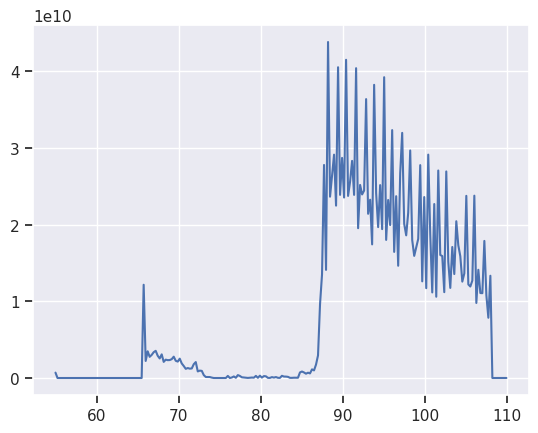

In [122]:
plt.plot(freq_range,GS)
plt.show()

In [119]:
fomdf=pd.DataFrame({'FOM':FOM_map})

In [120]:
# fomdf.to_csv('/home/saurabhs/Documents/Yogen_starfire/FOM_Nosynth.csv')